# Aula Prática: Machine Learning com Scikit-Learn

Este notebook foi preparado para uma aula introdutória e prática sobre **Machine Learning com Scikit-Learn**.

A proposta é trabalhar os principais conceitos de aprendizado supervisionado usando exemplos executáveis em Python.

## Objetivos da aula

Ao final desta atividade, o aluno deverá ser capaz de:

- Entender o que são `features` e `target`;
- Separar dados em treino e teste;
- Treinar modelos com Scikit-Learn;
- Fazer previsões com `.predict()`;
- Avaliar modelos usando métricas;


## 1. Instalação e importação das bibliotecas

Caso você ainda não tenha as bibliotecas instaladas, execute no terminal ou em uma célula do notebook:

```bash
pip install scikit-learn pandas matplotlib
```


In [ ]:
# Bibliotecas principais
import pandas as pd
import matplotlib.pyplot as plt

# Datasets prontos do Scikit-Learn
from sklearn.datasets import load_iris, load_diabetes, make_blobs

# Biblioteca para exportar e importar modelos.
import joblib

# Separação entre treino e teste
from sklearn.model_selection import train_test_split

# Modelos supervisionados
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression

# Modelo não supervisionado
from sklearn.cluster import KMeans

# Métricas de avaliação
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Parte A — Conceitos básicos

Em Machine Learning, normalmente dividimos os dados em duas partes:

- `X`: dados de entrada, também chamados de **features**, características ou variáveis independentes;
- `y`: resposta esperada, também chamada de **target**, alvo ou variável dependente.

Exemplo:

| idade | renda | tempo_cliente | comprou |
|---:|---:|---:|---:|
| 25 | 2500 | 2 | sim |
| 40 | 8000 | 8 | sim |
| 19 | 1200 | 1 | não |

Nesse exemplo:

- `X`: idade, renda e tempo_cliente;
- `y`: comprou.


# Parte B — Classificação com o Iris Dataset

Nesta etapa, vamos trabalhar com um problema de **classificação**.

Classificação é usada quando queremos prever uma **categoria**.

Exemplos:

- aprovado ou reprovado;
- spam ou não spam;
- fraude ou não fraude;
- espécie de uma flor.

O dataset Iris contém medidas de flores e o objetivo é prever a espécie da flor.


In [ ]:
# Carregando o dataset Iris
iris = load_iris()

# Criando um DataFrame para visualizar os dados de forma mais amigável
df_iris = pd.DataFrame(iris.data, columns=iris.feature_names)

# Adicionando a coluna target, que representa a espécie da flor
df_iris['target'] = iris.target

# Exibindo as primeiras linhas
df_iris


In [ ]:
# Nome das classes presentes no dataset
iris.target_names


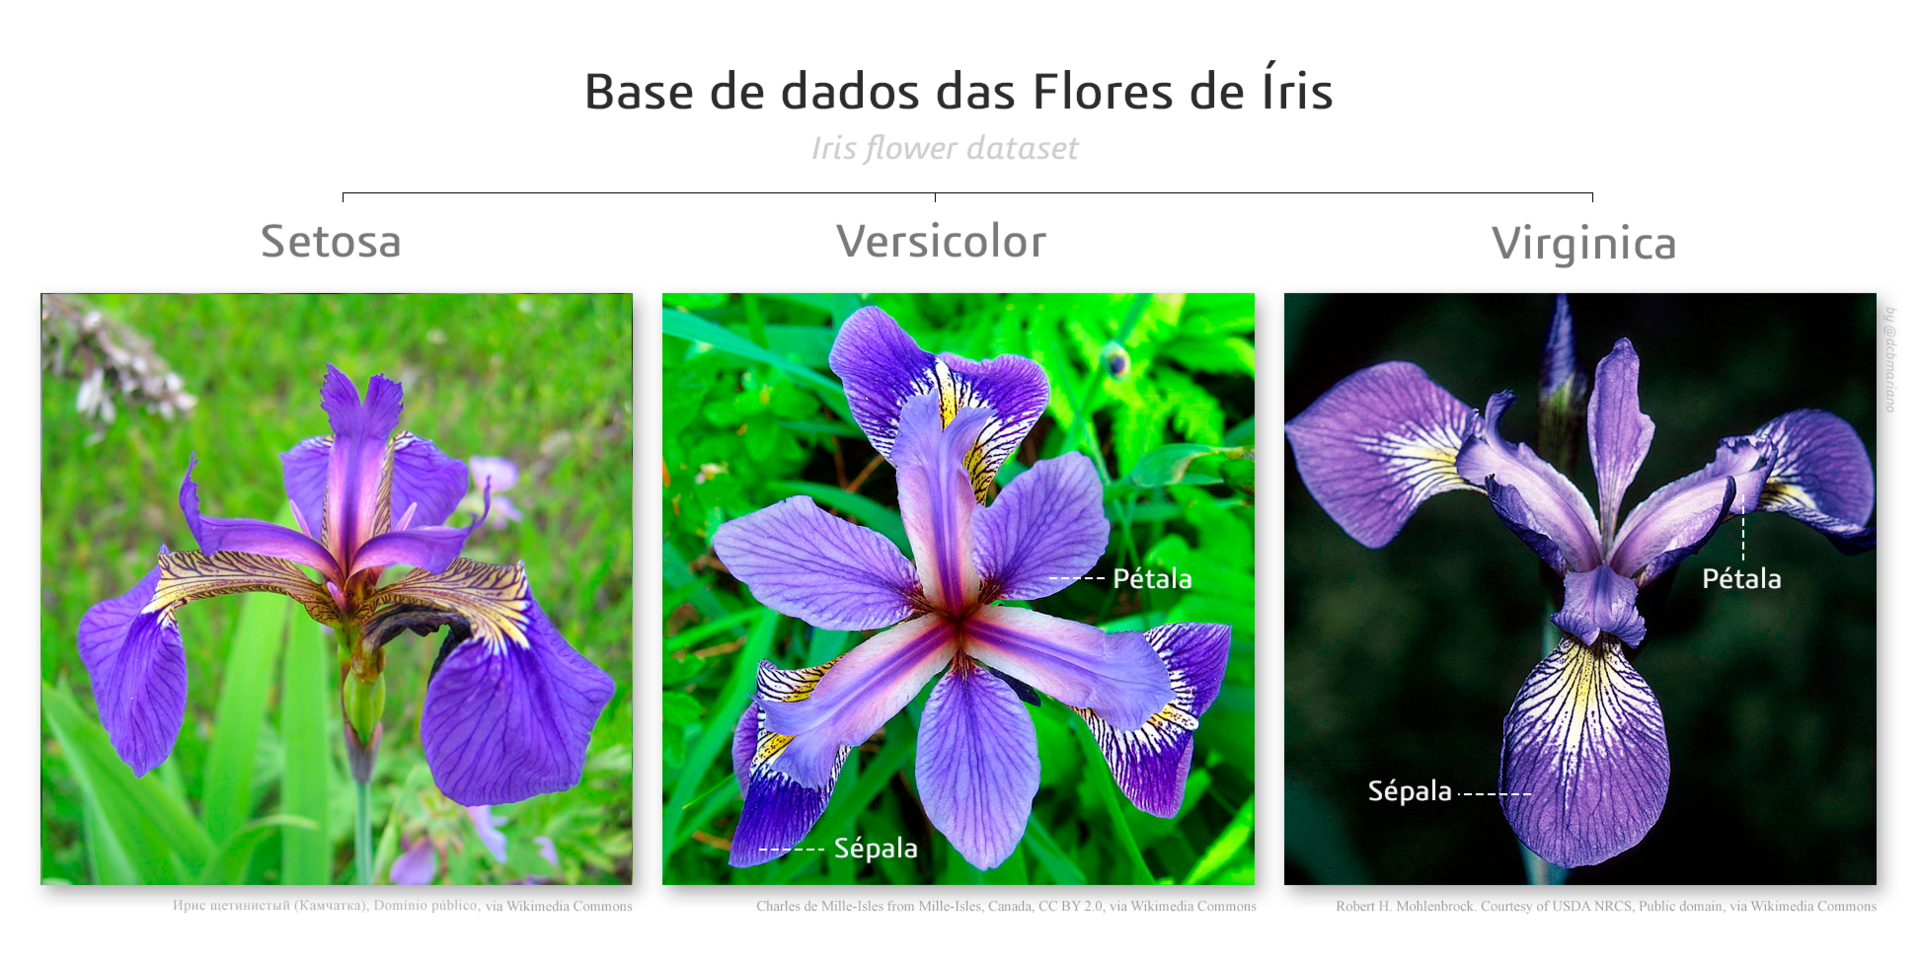

## Separando X e y

Agora vamos separar os dados de entrada e a resposta esperada.

- `X`: medidas das flores;
- `y`: espécie da flor.


In [ ]:
# X contém as features, ou seja, as características usadas para prever a espécie
X = df_iris[iris.feature_names]

# y contém o target, ou seja, a resposta esperada
y = df_iris['target']

print('Formato de X:', X.shape)
print('Formato de y:', y.shape)


## Separando treino e teste

Não devemos treinar e avaliar o modelo nos mesmos dados.

Por isso, dividimos os dados em:

- dados de treino: usados para ensinar o modelo;
- dados de teste: usados para avaliar o modelo em dados que ele ainda não viu.


In [ ]:
# Separando os dados em treino e teste
# test_size=0.2 indica que 20% dos dados serão usados para teste
# random_state=42 garante que a divisão seja reproduzível
# stratify=y mantém a proporção das classes no treino e no teste

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Treino:', X_train.shape)
print('Teste:', X_test.shape)


## Treinando um modelo KNN

O KNN, ou K-Nearest Neighbors, classifica uma nova amostra olhando para os vizinhos mais próximos.

Se `n_neighbors=3`, o modelo olha para os 3 vizinhos mais próximos e decide a classe com base neles.


In [ ]:
# Criando o modelo KNN
modelo_knn = KNeighborsClassifier(n_neighbors=3)

# Treinando o modelo
modelo_knn.fit(X_train, y_train)

# Fazendo previsões com os dados de teste
y_pred = modelo_knn.predict(X_test)

# Exibindo as primeiras previsões
y_pred[:10]

In [ ]:
# Avaliando a acurácia do modelo
acuracia = accuracy_score(y_test, y_pred)

print(f'Acurácia do modelo KNN: {acuracia:.2f}')


In [ ]:
# Relatório de classificação
# Mostra precision, recall e f1-score para cada classe

print(classification_report(y_test, y_pred, target_names=iris.target_names))


In [ ]:
# Matriz de confusão
# Linhas representam os valores reais
# Colunas representam os valores previstos

matriz = confusion_matrix(y_test, y_pred)

print(matriz)


## Exportando o modelo treinado para usarmos em outros projetos

In [ ]:
joblib.dump(modelo_knn, "knn_flores_iris.joblib")